# Tech Challenge - Fase 1: Sistema Inteligente de Suporte ao Diagnóstico
Este projeto visa implementar a base de um sistema de IA para um hospital universitário, focado em auxiliar a equipe clínica na análise inicial de dados médicos. O objetivo é realizar a triagem automática de risco de saúde mental utilizando algoritmos de Machine Learning.

**Tarefa Principal:** Classificação binária ("tem ou não tem risco") com base em dados estruturados.

## 1. Carregando os dados da tabela gold

In [0]:
df_spark = sql('SELECT * FROM kevin_catalog.gold.tb_saude_mental')
display(df_spark.limit(10))

age,gender,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,dummy_Employed,dummy_Self-employed,dummy_Student,dummy_Unemployed,dummy_Hybrid,dummy_On-site,dummy_Remote
56,0,1,1,6,6.2,3,28,17,54,59.7,1,true,false,false,false,false,true,false
46,1,0,1,10,9.0,4,30,11,85,54.9,1,false,false,true,false,false,true,false
32,1,1,0,7,7.7,2,24,7,62,61.3,1,true,false,false,false,false,true,false
25,1,1,1,3,5.4,0,24,12,70,69.0,1,false,true,false,false,false,true,false
38,1,1,1,3,9.9,3,17,9,63,69.3,1,false,false,false,true,false,true,false
36,0,0,0,8,7.1,5,25,8,72,58.4,1,false,false,true,false,false,false,true
40,0,0,0,7,6.5,6,28,6,46,60.4,1,true,false,false,false,true,false,false
28,1,0,0,8,3.1,0,7,18,88,93.2,1,true,false,false,false,false,false,true
28,1,1,0,6,9.7,2,14,9,85,71.2,1,false,true,false,false,false,true,false
41,1,1,0,10,4.4,7,13,2,23,80.1,1,false,true,false,false,false,true,false


## 2. Exploração e Limpeza de Dados
Nesta fase, carregamos os dados em Pandas para análise estatística e visualização.

In [0]:
# Conversão para Pandas para facilitar a análise exploratória
df_pd = df_spark.toPandas()

### Importanto bib para verificar dados nulos

In [0]:
!pip install missingno

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


age                       0
gender                    0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dummy_Employed            0
dummy_Self-employed       0
dummy_Student             0
dummy_Unemployed          0
dummy_Hybrid              0
dummy_On-site             0
dummy_Remote              0
dtype: int64

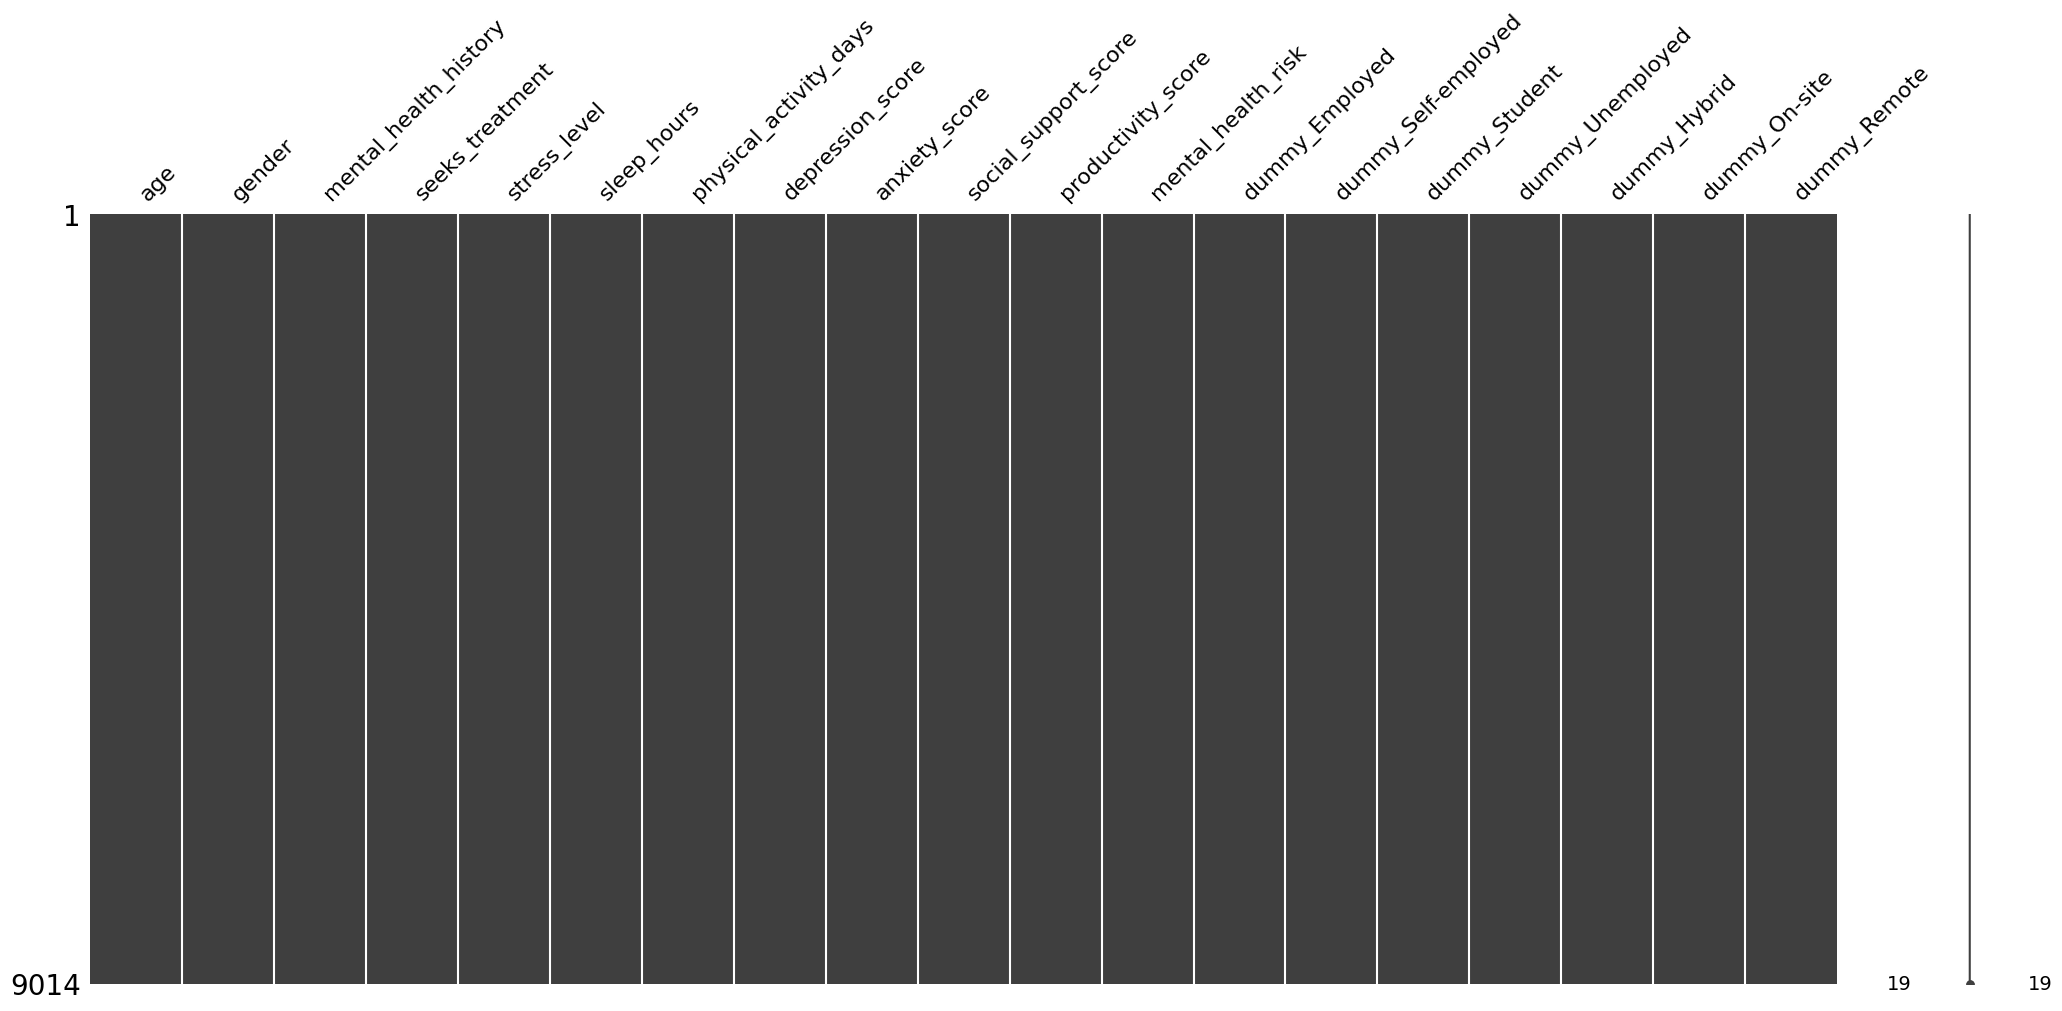

In [0]:
import missingno as msno

# Visualização de dados ausentes
msno.matrix(df_pd)
df_pd.isnull().sum()

### Análise de Distribuição e Correlação
Verificamos como os dados estão distribuídos e como as variáveis se relacionam.

<Axes: >

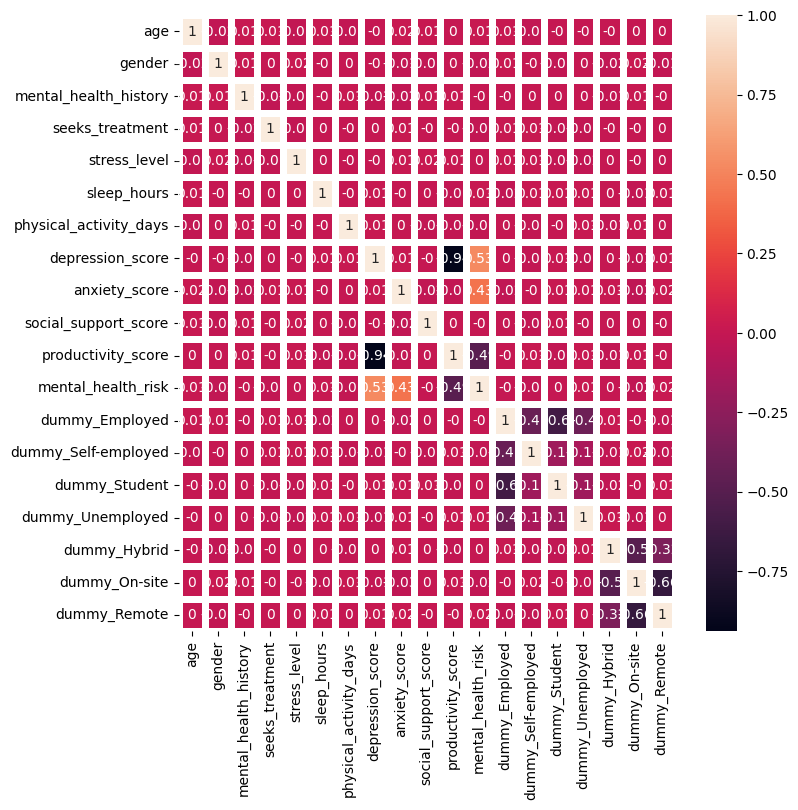

In [0]:
import matplotlib.pyplot as plt
import seaborn as sb

# Matriz de correlação para identificar variáveis que impactam o diagnóstico
corr_matriz = df_pd.corr().round(2)
fog, ax = plt.subplots(figsize=(8,8))
sb.heatmap(data=corr_matriz, annot=True, linewidths=5, ax=ax)

## 3. Pré-processamento
Preparamos os dados separando as características (X) do alvo (y) e realizando o escalonamento.

In [0]:
from sklearn.model_selection import *
from sklearn.model_selection import train_test_split

In [0]:
# Seleção das variáveis preditoras
x = df_pd[
    [
        "age",
        "gender",
        "mental_health_history",
        "seeks_treatment",
        "stress_level",
        "sleep_hours",
        "physical_activity_days",
        "depression_score",
        "anxiety_score",
        "social_support_score",
        "productivity_score",
        "dummy_Employed", 
        "dummy_Self-employed", 
        "dummy_Student", 
        "dummy_Unemployed",
        "dummy_Hybrid", 
        "dummy_On-site", 
        "dummy_Remote"
    ]

age                       0
gender                    0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dummy_Employed            0
dummy_Self-employed       0
dummy_Student             0
dummy_Unemployed          0
dummy_Hybrid              0
dummy_On-site             0
dummy_Remote              0
]

In [0]:
# Seleção da variável alvo (diagnóstico)
y = df_pd['mental_health_risk']

### Separação de base de treinamento e teste

In [0]:
# tamanho da base de teste = 20%
# random_state = 42. 
# Distribuição aleatória dos dados para garantir que a distribuição de classes seja a mesma em ambos os conjuntos de treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)


In [0]:
# Padronização
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
scaler.fit(x_train)

x_train_escalonado = scaler.transform(x_train)
x_test_escalonado = scaler.transform(x_test)

## KNN

In [0]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

In [0]:
# Testando diferentes valores de K para encontrar o menor erro médio
error = []

for i in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=i) # n_neighbors = 5 é o número de vizinhos mais próximos que serão considerados para fazer a predição 
    knn.fit(x_train_escalonado, y_train)
    pred_i = knn.predict(x_test_escalonado)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Erro Médio')

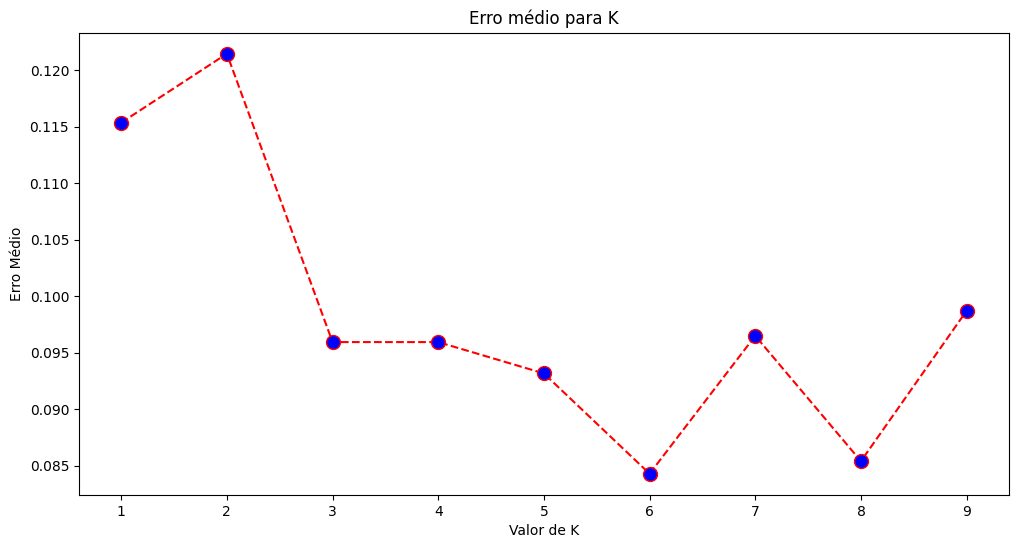

In [0]:
plt.figure(figsize=(12,6))
plt.plot(range(1,10), error, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)

plt.title("Erro médio para K")
plt.xlabel("Valor de K")
plt.ylabel("Erro Médio")

In [0]:
# Treinamento final com K=6
modelo_class = KNeighborsClassifier(n_neighbors=6)
modelo_class.fit(x_train_escalonado, y_train)
y_predict = modelo_class.predict(x_test_escalonado)

### Avaliação e Interpretação

In [0]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(accuracy_score(y_test, y_predict))

0.915696062118691


In [0]:
print("Relatório de Classificação KNN:")
print(classification_report(y_test, y_predict))

Relatório de Classificação KNN:
              precision    recall  f1-score   support

           0       0.79      0.70      0.74       314
           1       0.94      0.96      0.95      1489

    accuracy                           0.92      1803
   macro avg       0.86      0.83      0.85      1803
weighted avg       0.91      0.92      0.91      1803



Text(45.722222222222214, 0.5, 'Real')

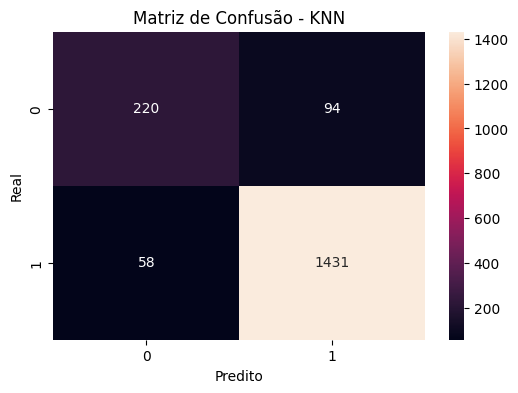

In [0]:
plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, y_predict), annot=True, fmt='d')
plt.title("Matriz de Confusão - KNN")
plt.xlabel("Predito")
plt.ylabel("Real")

##  RANDOM FOREST

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [0]:
# Instanciando o modelo (usando 100 árvores de decisão) 
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [0]:
# Treinamento do modelo com os dados escalonado
modelo_rf.fit(x_train_escalonado, y_train)

RandomForestClassifier(random_state=42)

In [0]:
# Predição com os dados de teste
y_predict_rf = modelo_rf.predict(x_test_escalonado)

In [0]:
# Avaliação do desempenho
print("--- Relatório de Classificação: Random Forest ---")
print(classification_report(y_test, y_predict_rf))

--- Relatório de Classificação: Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       314
           1       0.99      1.00      0.99      1489

    accuracy                           0.99      1803
   macro avg       0.99      0.97      0.98      1803
weighted avg       0.99      0.99      0.99      1803



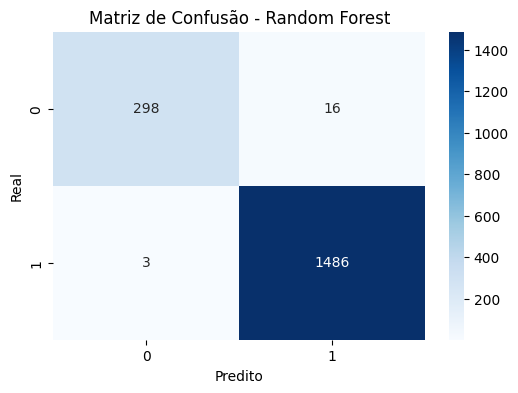

In [0]:
# 5. Visualização da Matriz de Confusão
plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, y_predict_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

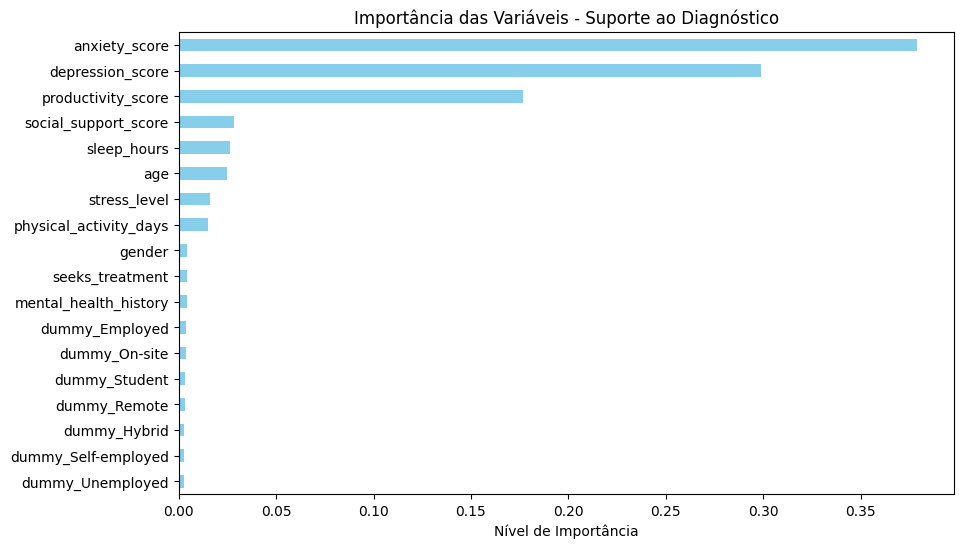

In [0]:
# Interpretação: Feature Importance (Importância das Variáveis) 
# Este gráfico mostra quais dados médicos mais impactaram a decisão do modelo 
importancias = pd.Series(modelo_rf.feature_importances_, index=x.columns)
importancias_ordenadas = importancias.sort_values(ascending=True)

plt.figure(figsize=(10,6))
importancias_ordenadas.plot(kind='barh', color='skyblue')
plt.title("Importância das Variáveis - Suporte ao Diagnóstico")
plt.xlabel("Nível de Importância")
plt.show()

In [0]:
# Teste de um novo paciente
novo_dado = pd.DataFrame([[36,	0,	0,	0,	8,	7.1,	5,	25,	8,	72,	58.4, False,	False,	True,	False,	False,	False,	True]], columns=x.columns)

# 1. O passo crucial: Escalonar usando o MESMO scaler do treino
novo_dado_escalonado = scaler.transform(novo_dado)

# 2. Fazer a previsão
previsao = modelo_class.predict(novo_dado_escalonado)

print(f"O risco de saúde mental previsto é: {previsao[0]}")

O risco de saúde mental previsto é: 1
